In [2]:
from convokit import Corpus, download
import nltk
import gensim.downloader as api

corpus = Corpus(filename=download("movie-corpus"))
nltk.download("stopwords")
embeddings_50d = api.load("glove-twitter-50")
embeddings_100d = api.load("glove-wiki-gigaword-100")

In [3]:
# Preprocess data
from process import preprocess

X_all, y_all = preprocess(list(corpus.iter_speakers()))
print(len(X_all), len(y_all))

8962 8962


In [5]:
# Split data (70% for training set, 15% for dev set, 15% for test set)
from sklearn.model_selection import train_test_split

X_train_and_dev, X_test, y_train_and_dev, y_test = train_test_split(X_all, y_all, test_size=0.15, random_state=0)
X_train, X_dev, y_train, y_dev = train_test_split(X_train_and_dev, y_train_and_dev, test_size=15/85, random_state=0)
print(len(X_train), len(X_dev), len(X_test))

6272 1345 1345


In [6]:
# Extract features and vectorize as necessary
from process import get_unigrams, get_average_embeddings
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

v = DictVectorizer()
X_train_unigrams = v.fit_transform(get_unigrams(X_train))
X_dev_unigrams = v.transform(get_unigrams(X_dev))
X_test_unigrams = v.transform(get_unigrams(X_test))

X_train_avgemb50 = get_average_embeddings(X_train, embeddings_50d, 50)
X_dev_avgemb50 = get_average_embeddings(X_dev, embeddings_50d, 50)
X_test_avgemb50 = get_average_embeddings(X_test, embeddings_50d, 50)

X_train_avgemb100 = get_average_embeddings(X_train, embeddings_100d, 100)
X_dev_avgemb100 = get_average_embeddings(X_dev, embeddings_100d, 100)
X_test_avgemb100 = get_average_embeddings(X_test, embeddings_100d, 100)

mlb = MultiLabelBinarizer()
y_train_true = mlb.fit_transform(y_train)
y_dev_true = mlb.transform(y_dev)
y_test_true = mlb.transform(y_test)

In [25]:
# Print most common unigrams by genre in training data
from collections import Counter, defaultdict

unigrams_by_genre = defaultdict(Counter)
for X,y in zip(get_unigrams(X_train), y_train):
    for genre in y:
        unigrams_by_genre[genre].update(X)
for genre, unigrams in sorted(unigrams_by_genre.items(), key=lambda kv: kv[0]):
    print(genre, ":\t", ", ".join([u[0] for u in unigrams.most_common(50)]))

action 	 know, get, like, one, got, right, think, go, want, going, us, see, u, well, back, good, time, let, come, could, man, tell, way, would, take, oh, yes, look, something, yeah, never, say, make, need, two, okay, sir, little, thing, sure, gonna, mean, maybe, people, give, find, really, much, still, said
adventure 	 know, get, one, like, got, right, go, going, well, think, want, oh, see, us, yes, come, u, time, good, could, back, let, take, tell, would, way, never, look, say, something, man, sir, make, need, must, two, yeah, thing, find, little, sure, people, okay, much, mean, give, mr, life, sorry, really
animation 	 u, know, get, got, right, huh, well, one, like, oh, yeah, think, see, go, want, tell, going, back, time, would, come, heh, us, good, man, gonna, yes, let, could, take, something, say, way, make, uh, hey, never, look, mr, find, need, mean, thing, okay, sure, really, much, must, people, help
biography 	 know, like, want, get, got, one, well, think, right, yes, good, go, 

In [8]:
# Perform grid search on dev set
from train_eval import grid_search_dev
dev_hamming_loss, dev_f1, dev_precision, dev_recall = grid_search_dev(
    X_train_unigrams, X_dev_unigrams,
    X_train_avgemb50, X_dev_avgemb50,
    X_train_avgemb100, X_dev_avgemb100,
    y_train_true, y_dev_true
)

KeyboardInterrupt: 

In [9]:
# Evaluate test set
from train_eval import train_and_get_test_metrics
test_hamming_loss, test_f1, test_precision, test_recall = train_and_get_test_metrics(
    X_train_unigrams, X_test_unigrams,
    y_train_true, y_test_true
)

In [56]:
# Print classification report
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier
import pandas as pd
import matplotlib.pyplot as plt

clf = MultiOutputClassifier(MultinomialNB(alpha=0.1))
clf.fit(X_train_unigrams, y_train_true)
y_test_pred = clf.predict(X_test_unigrams)
print(classification_report(y_test_true, y_test_pred, target_names=mlb.classes_, digits=4))

              precision    recall  f1-score   support

      action     0.6730    0.5252    0.5900       337
   adventure     0.6307    0.5236    0.5722       212
   animation     0.4444    0.1176    0.1860        34
   biography     0.6383    0.4478    0.5263        67
      comedy     0.6168    0.5659    0.5903       364
       crime     0.6175    0.6699    0.6426       306
       drama     0.7497    0.8422    0.7933       754
      family     0.5000    0.1935    0.2791        31
     fantasy     0.6190    0.3514    0.4483       148
     history     0.5714    0.4828    0.5234        58
      horror     0.7391    0.4645    0.5705       183
       music     0.7778    0.2800    0.4118        25
     musical     0.6667    0.1250    0.2105        16
     mystery     0.6667    0.4434    0.5326       221
     romance     0.5477    0.5236    0.5354       296
      sci-fi     0.7346    0.5242    0.6118       227
       sport     0.2857    0.1818    0.2222        11
    thriller     0.7359    

/opt/miniconda3/envs/cosi114a-fp/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Graph precision and recall for each label
cr = classification_report(y_test_true, y_test_pred, target_names=mlb.classes_, output_dict=True)
cr = dict(sorted(cr.items(), key = lambda i: i[1]["support"])[:-4]) # sort by support and remove average metrics
pd.DataFrame(cr).iloc[:2, :20].T.plot(kind='barh')
plt.show()

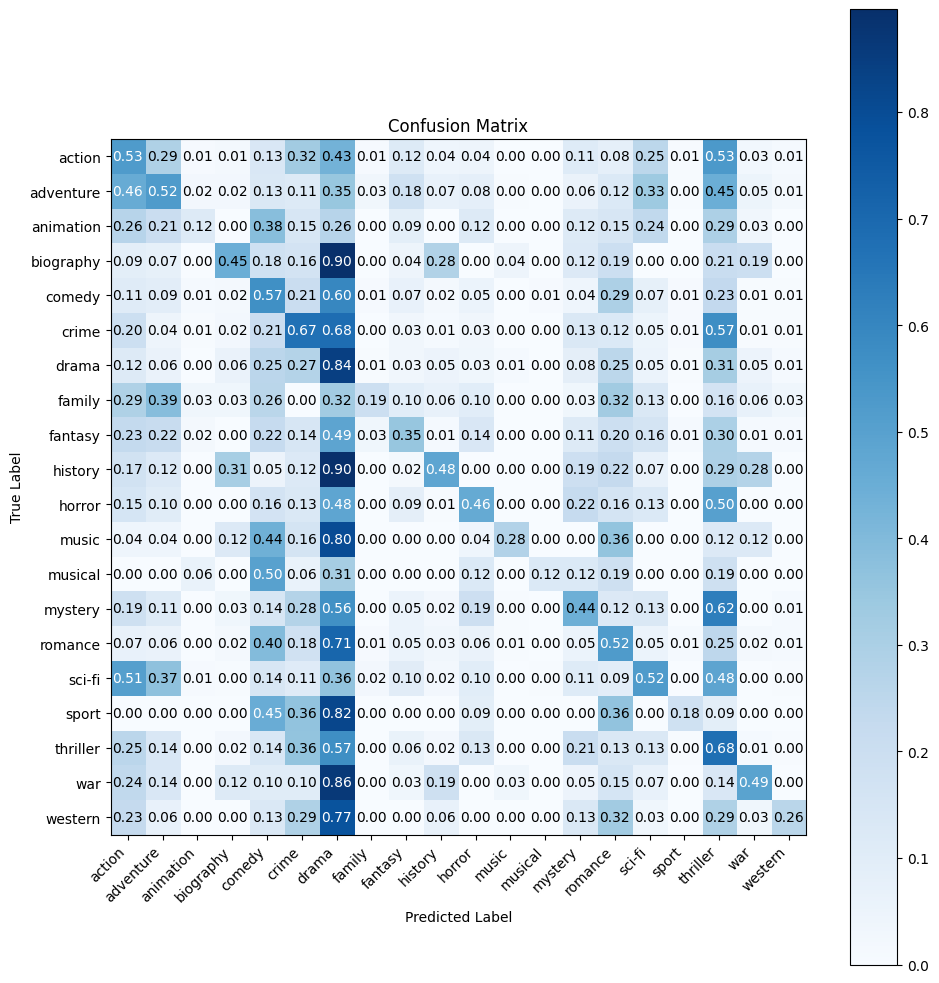

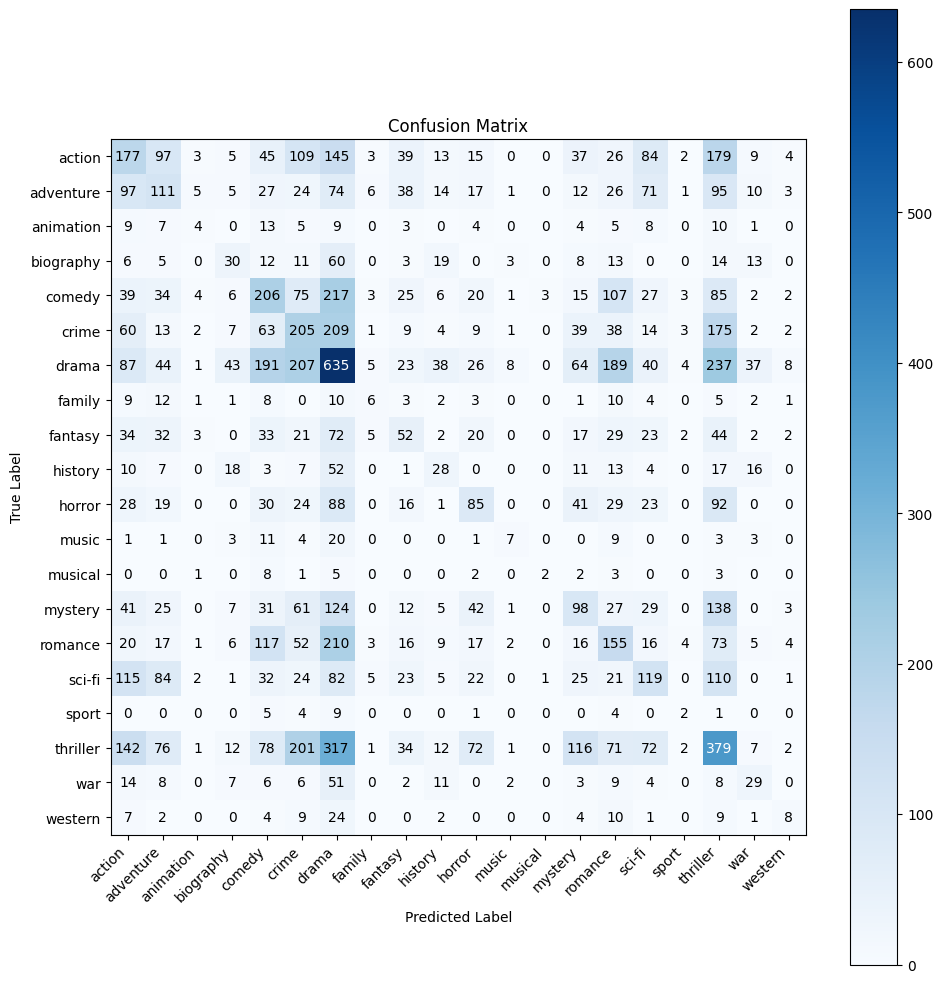

In [10]:
# Plot error matrix
from visualize import plot_error_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier

clf = MultiOutputClassifier(MultinomialNB(alpha=0.1)).fit(X_train_unigrams, y_train_true)
y_test_pred = clf.predict(X_test_unigrams)
plot_error_matrix(y_test_true, y_test_pred, mlb.classes_)
plot_error_matrix(y_test_true, y_test_pred, mlb.classes_, normalize=False)